In [13]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import h5py
from trainingTools import make_flow, train
import torch
import torch.nn as nn
import json
import helper_functions as hf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from quakSpaceTools import LossEval
mean_reference = "BKG"
lossEval = LossEval(mean_reference=mean_reference,overwrite=False)

extras =  []


In [10]:
base = "combined_trainings/M80-400/"
with open(base+"flow_kwargs.json","r") as f:
    js = json.load(f)
variables = js['variables']
rangeScale = js['rangeScale']

In [12]:
means, sds = lossEval.loadMeans(variables)
mins,maxes = lossEval.loadMinMax(variables)

In [20]:
data = hf.loadData("BKG",variables,dEta_cut=1.3,mode="all",sideband=False)

100%|██████████| 80/80 [00:05<00:00, 15.82it/s]


In [21]:
data = data-means
scale = np.where(np.abs(maxes-means)>np.abs(mins-means),np.abs(maxes-means),np.abs(mins-means))
data = js['rangeScale']*(data/scale)

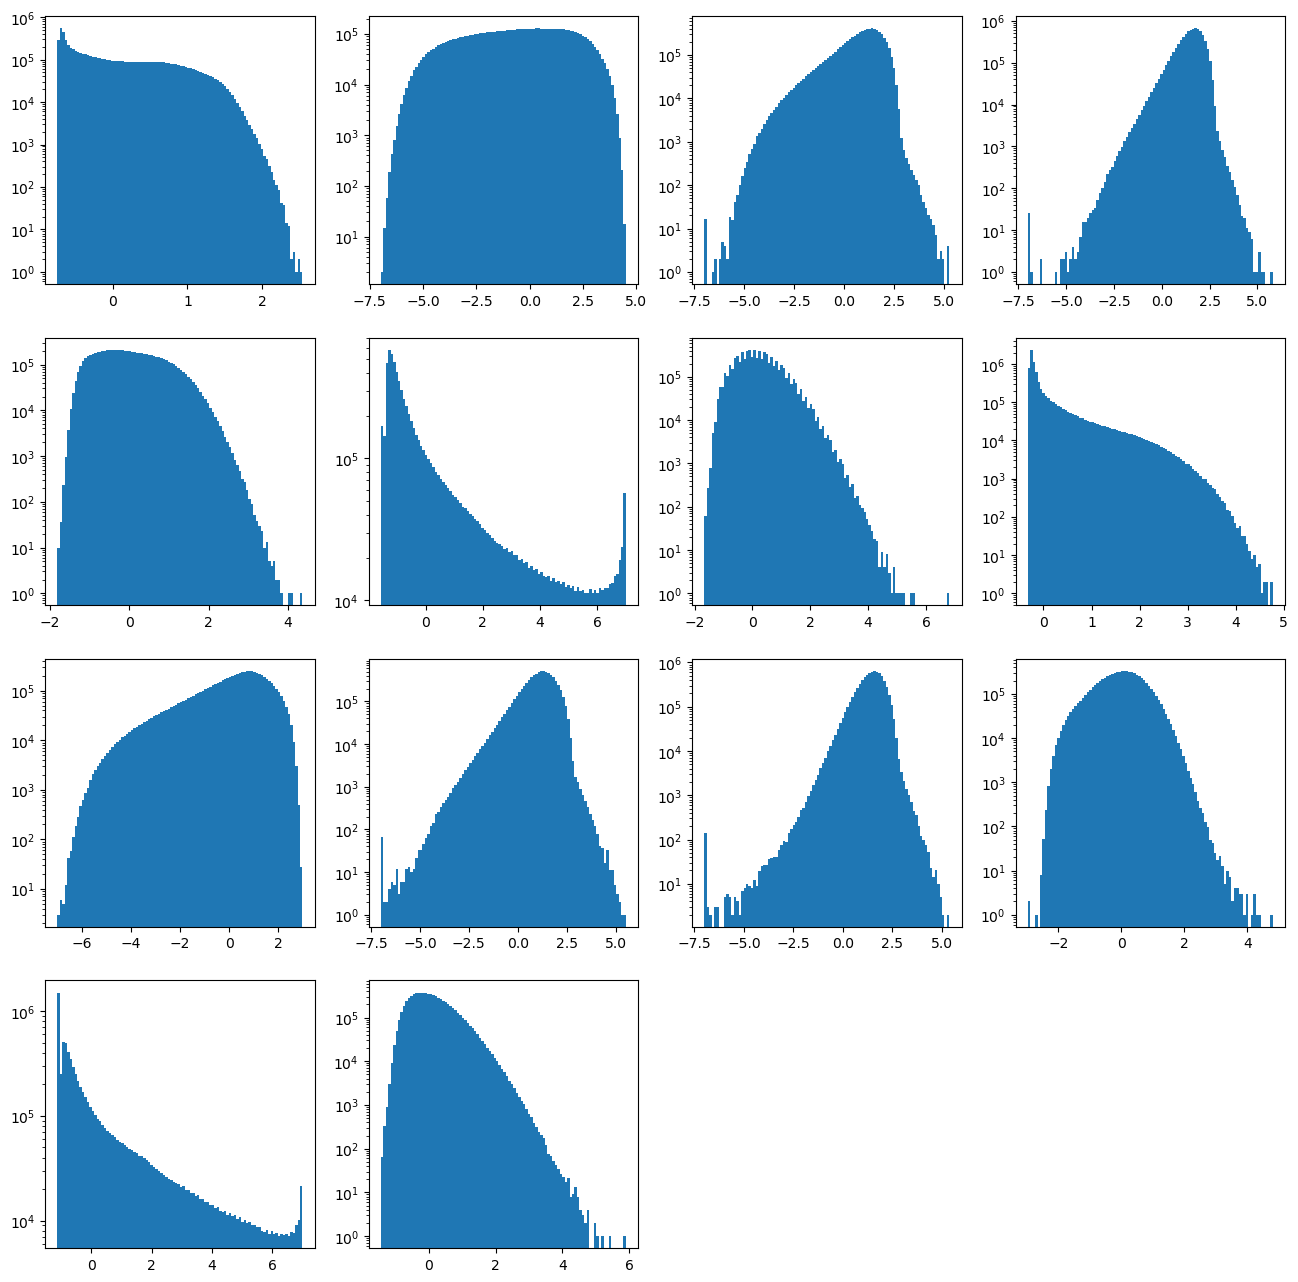

In [22]:
plt.figure(figsize=(16,16))
for i in range(len(variables)):
    plt.subplot(4,4,i+1)
    h = plt.hist(data[:,i],bins=100)
    plt.yscale('log')

In [24]:
from trainingTools import make_flow
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = make_flow(len(variables),js)
model.load_state_dict(torch.load(base+"M80-400.pt"))
model.eval()
model = model.to(device)

In [32]:
with torch.no_grad():
    test = -model.log_prob(inputs=data[:100000])[0].detach().cpu().numpy()

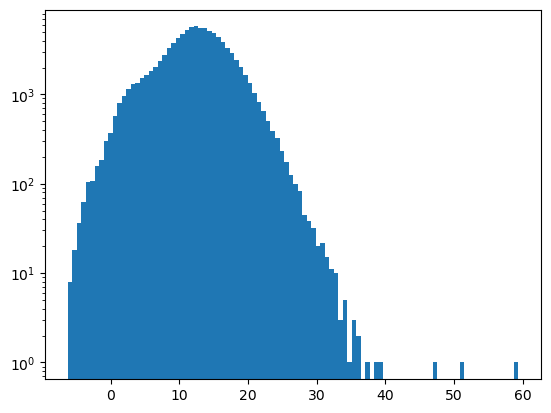

In [34]:
h = plt.hist(test,bins=100)
plt.yscale('log')

In [35]:
bad = data[:100000][test<0]

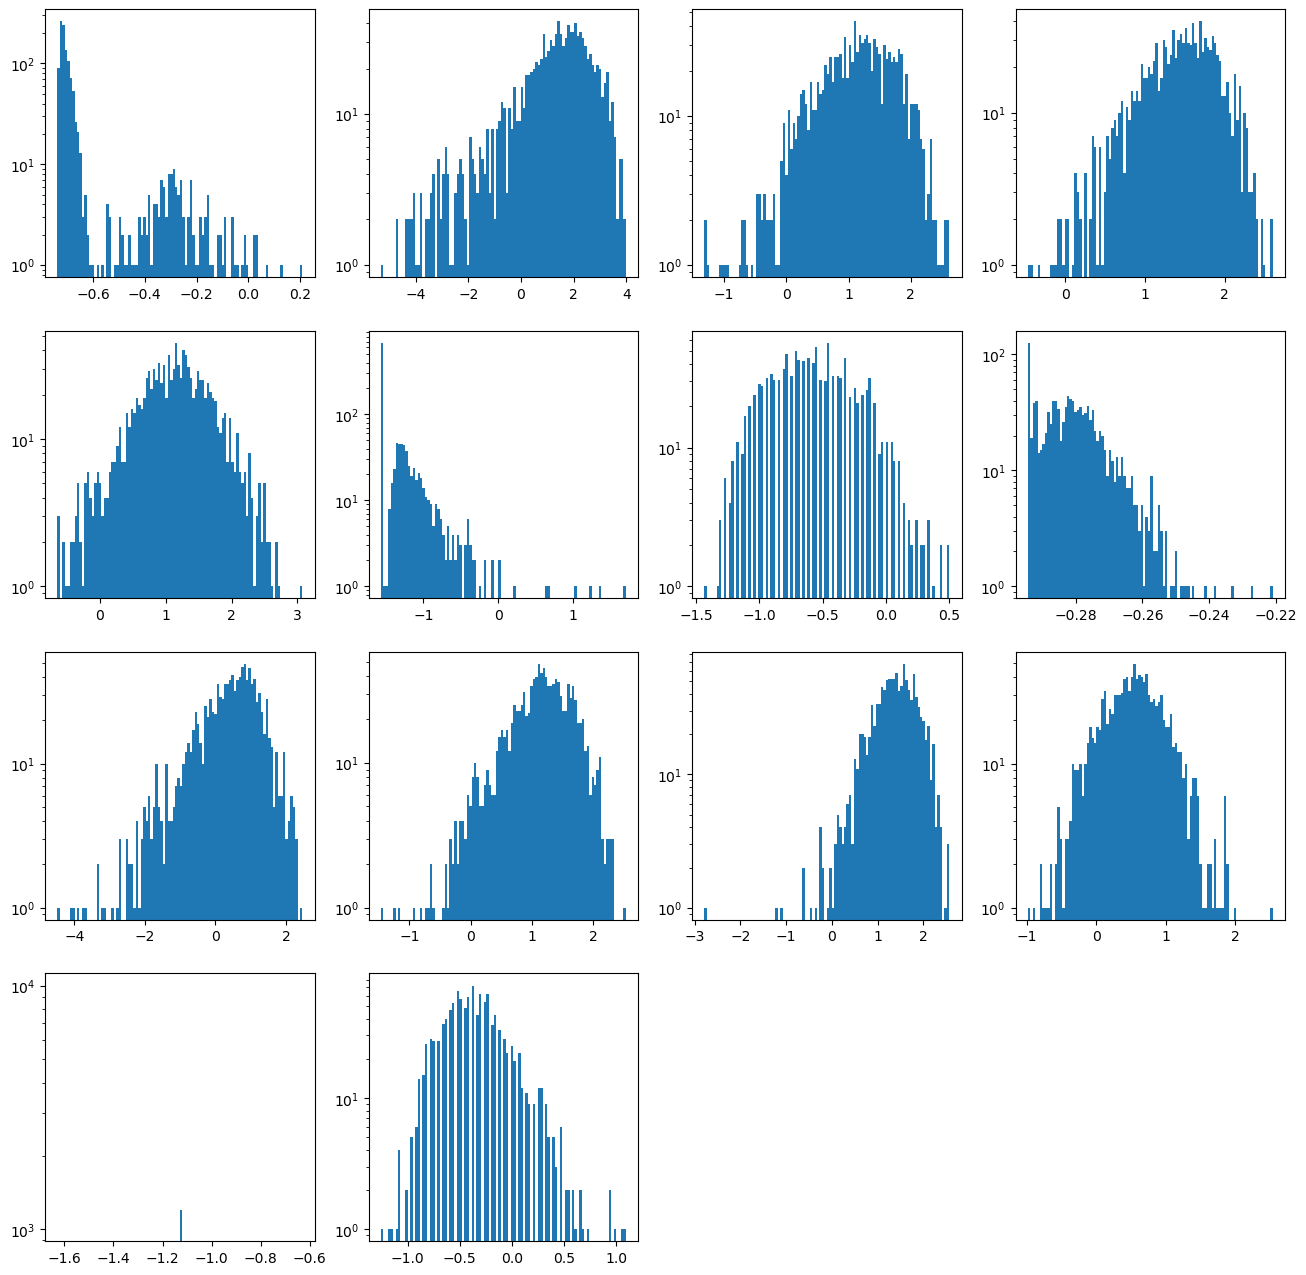

In [36]:
plt.figure(figsize=(16,16))
for i in range(len(variables)):
    plt.subplot(4,4,i+1)
    h = plt.hist(bad[:,i],bins=100)
    plt.yscale('log')